In [1]:
import pandas as pd
import numpy as np
import re
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

/Users/josepomarino/Desktop/Data Projects/song_lyrics/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_json("../data/processed/filtered_songs.json")

In [3]:
print(df["artist"].value_counts())        
print(df.isnull().sum())                 
print(df["lyrics"].str.len().describe()) 

artist
Charli xcx           195
Carly Rae Jepsen     142
Ariana Grande        139
Kacey Musgraves      126
Sabrina Carpenter    105
Ethel Cain            89
Tate McRae            74
Maisie Peters         66
Maggie Rogers         64
Billie Eilish         61
Gracie Abrams         59
Lorde                 58
Rachel Chinouriri     54
Olivia Dean           41
Holly Humberstone     40
Reneé Rapp            39
Olivia Rodrigo        34
Chappell Roan         27
Addison Rae           16
Audrey Hobert         12
Name: count, dtype: int64
artist              0
title               0
album               0
release_date       43
lyrics              0
album_cover_url     0
dtype: int64
count    1441.00000
mean     1553.84941
std       590.30433
min       169.00000
25%      1159.00000
50%      1540.00000
75%      1895.00000
max      5381.00000
Name: lyrics, dtype: float64


In [6]:
df['lyrics'][0]

'Girl, it\'s so confusing sometimes to be a girl\nGirl, girl, girl, girl\nGirl, it\'s so confusing sometimes to be a girl\nGirl, girl, girl, girl\nGirl, how do you feel being a girl?\nGirl, girl, girl\nHow do you feel being a girl?\nGirl, girl, girl\nMan, I don\'t know, I\'m just a girl\nGirl, girl, girl, girl\n\nYeah, I don\'t know if you like me\nSometimes I think you might hate me\nSometimes I think I might hate you\nMaybe you just wanna be me\nYou always say, "Let\'s go out"\nSo we go eat at a restaurant\nSometimes it feels a bit awkward\n\'Cause we don\'t have much in common\n\nPeople say we\'re alike\nThey say we\'ve got the same hair\nWe talk about making music\nBut I don\'t know if it\'s honest\nCan\'t tell if you wanna see me\nFalling over and failing\nAnd you can\'t tell what you\'re feeling\nI think I know how you feel\n\nGirl, it\'s so confusing sometimes to be a girl\nGirl, girl, girl, girl\nGirl, it\'s so confusing sometimes to be a girl\nGirl, girl, girl, girl\nGirl, how

In [3]:
# Define list of filler words
FILLER_WORDS = {
    "yeah", "yea", "oh", "uh", "ah", "ooh", "ayy", "ay", "ya",
    "na", "la", "woah", "whoa", "huh", "mm", "mmm"
}

def clean_text(text: str) -> str:
    
    if not isinstance(text, str):
        return ""
    
    text = re.sub(r"\[.*?\]", "", text)        # remove [Verse 1], [Chorus] etc.
    text = re.sub(r"\s+", " ", text)           # collapse multiple whitespace
    return text.strip()

In [4]:
preprocessed_lyrics = df["lyrics"].apply(clean_text)

In [5]:
preprocessed_lyrics[0]

'Girl, it\'s so confusing sometimes to be a girl Girl, girl, girl, girl Girl, it\'s so confusing sometimes to be a girl Girl, girl, girl, girl Girl, how do you feel being a girl? Girl, girl, girl How do you feel being a girl? Girl, girl, girl Man, I don\'t know, I\'m just a girl Girl, girl, girl, girl Yeah, I don\'t know if you like me Sometimes I think you might hate me Sometimes I think I might hate you Maybe you just wanna be me You always say, "Let\'s go out" So we go eat at a restaurant Sometimes it feels a bit awkward \'Cause we don\'t have much in common People say we\'re alike They say we\'ve got the same hair We talk about making music But I don\'t know if it\'s honest Can\'t tell if you wanna see me Falling over and failing And you can\'t tell what you\'re feeling I think I know how you feel Girl, it\'s so confusing sometimes to be a girl Girl, girl, girl, girl Girl, it\'s so confusing sometimes to be a girl Girl, girl, girl, girl Girl, how do you feel being a girl? Girl, gir

In [6]:
MAX_WORDS_PER_CHUNK = 200
CHUNK_OVERLAP = 30

def chunk_lyrics(lyrics: str, max_words: int = MAX_WORDS_PER_CHUNK, overlap: int = CHUNK_OVERLAP) -> list[str]:
    
    words = lyrics.split()
    
    if len(words) <= max_words:
        return words
    
    chunks = []
    start = 0
    
    while start < len(words):
        end = min(start + max_words, len(words))
        chunks.append(" ".join(words[start:end]))
        
        if end == len(words):
            break
        
        start += max_words - overlap
    
    return chunks
    

In [7]:
MODEL_NAME = "all-MiniLM-L6-v2"
EMBEDDING_DIM = 384

model = SentenceTransformer(MODEL_NAME)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6610.16it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [17]:
emb = model.encode(chunk_lyrics(preprocessed_lyrics[0])[0])

In [10]:
emb.shape

(384,)

In [8]:
def embed_song(lyrics: str, model = model, embedding_dim: int = EMBEDDING_DIM):
    
    # If the lyrics are not a string, or have no words: return zeros
    if not isinstance(lyrics, str) or len(lyrics.strip()) == 0:
        return np.zeros(embedding_dim)
    
    # Chunk the songs due to the model's token limit
    chunks = chunk_lyrics(lyrics)
    chunk_embeddings = model.encode(
        chunks,
        batch_size=32,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True   # L2-normalize each chunk to normalize vector magnitudes for different sized chunks
    )
    
    # Average the chunks weighted by the length of the chunks
    word_counts = np.array([len(c.split()) for c in chunks], dtype = float)
    weights = word_counts / word_counts.sum()
    averaged = np.average(chunk_embeddings, axis = 0, weights = weights)
    
    # Re-normalize the averaged vector
    norm = np.linalg.norm(averaged)
    if norm > 0:
        averaged = averaged / norm

    return averaged

In [9]:
embeddings = np.zeros((len(df), EMBEDDING_DIM), dtype=np.float32)

for i, lyrics in enumerate(tqdm(preprocessed_lyrics, desc="Embedding")):
    embeddings[i] = embed_song(lyrics, model)

Embedding: 100%|██████████| 1441/1441 [00:37<00:00, 38.75it/s]


In [10]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_neighbors=10)
umap_embedding = reducer.fit_transform(embeddings)
umap_embedding.shape

(1441, 2)

In [13]:
type(umap_embedding)

numpy.ndarray

Text(0.5, 1.0, 'UMAP projection of song lyrics')

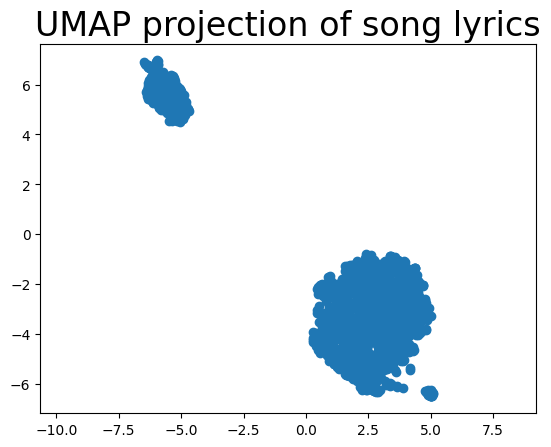

In [44]:
plt.scatter(
    umap_embedding[:, 0],
    umap_embedding[:, 1])
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of song lyrics', fontsize=24)

In [35]:
import plotly.express as px

# Build a plotting DataFrame
plot_df = pd.DataFrame({
    "UMAP 1":  umap_embedding[:, 0],
    "UMAP 2":  umap_embedding[:, 1],
    "artist":  df["artist"],
    "title":   df["title"],
    "album":   df["album"],
})

fig = px.scatter(
    plot_df,
    x="UMAP 1",
    y="UMAP 2",
    color="artist",
    hover_name="title",             # song title shown as bold header on hover
    hover_data={                    # additional info in hover tooltip
        "artist": True,
        "album":  True,
        "UMAP 1": ":.3f",
        "UMAP 2": ":.3f",
    },
    title="UMAP Projection of Song Lyrics — Colored by Artist",
    template="plotly_dark",         # clean dark background, swap to "plotly_white" if preferred
    opacity=0.8,
    size_max=8,
)

fig.update_traces(
    marker=dict(size=6, line=dict(width=0.5, color="white")),
    selector=dict(mode="markers")
)

fig.update_layout(
    width=1100,
    height=700,
    legend=dict(
        title="Artist",
        itemsizing="constant",
        bgcolor="rgba(0,0,0,0.3)",
        bordercolor="rgba(255,255,255,0.2)",
        borderwidth=1
    ),
    font=dict(size=12),
    title_font=dict(size=16),
    xaxis=dict(showgrid=False, zeroline=False),
    yaxis=dict(showgrid=False, zeroline=False),
)

fig.show()

In [42]:
import umap
import matplotlib.pyplot as plt

df = pd.read_json("../data/processed/final_songs.json")
embeddings = np.load("../data/cache/llm_embedding.npy")

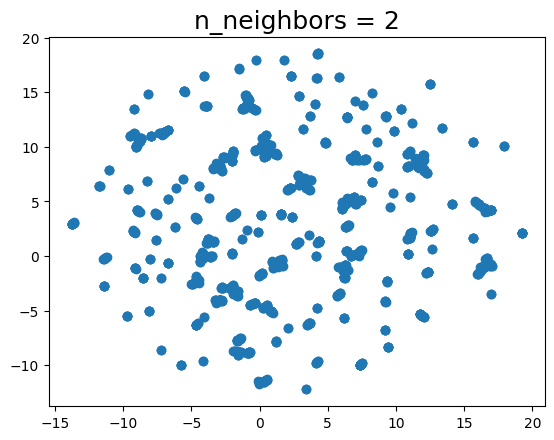

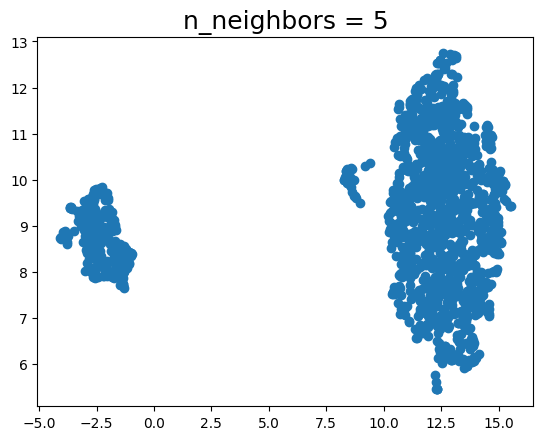

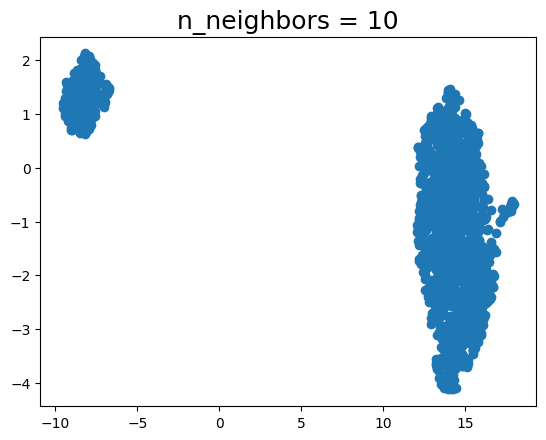

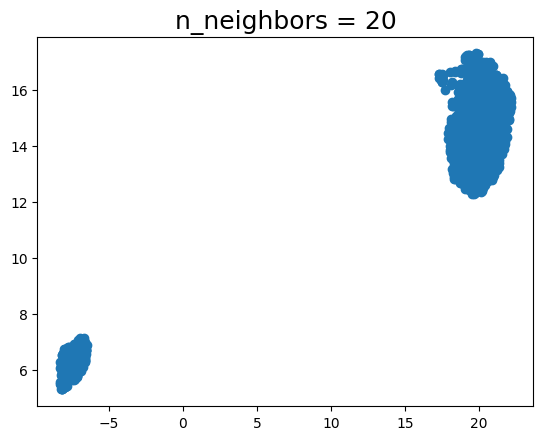

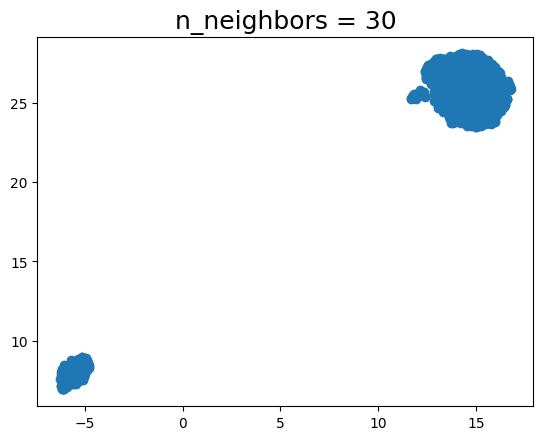

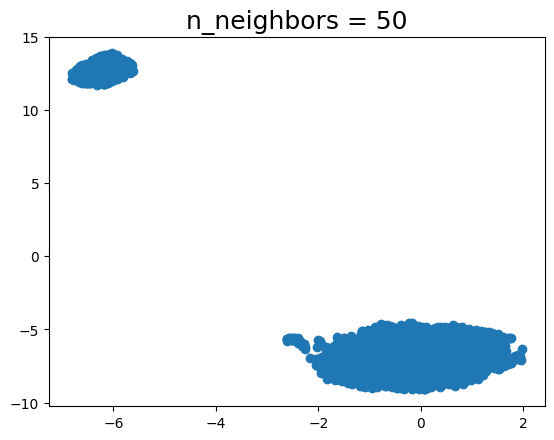

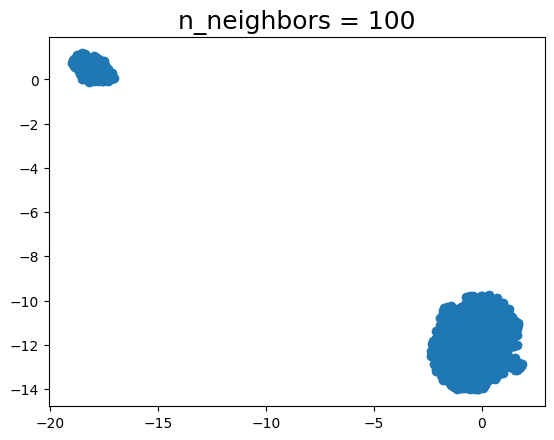

In [46]:
def draw_umap(n_neighbors=15, min_dist=0.1, metric='euclidean', title=''):
    fit = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric
    )
    umap_embedding = fit.fit_transform(embeddings)
    
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.scatter(umap_embedding[:,0], umap_embedding[:,1])
    plt.title(title, fontsize=18)

for n in (2, 5, 10, 20, 30, 50, 100):
    draw_umap(n_neighbors=n, title='n_neighbors = {}'.format(n))

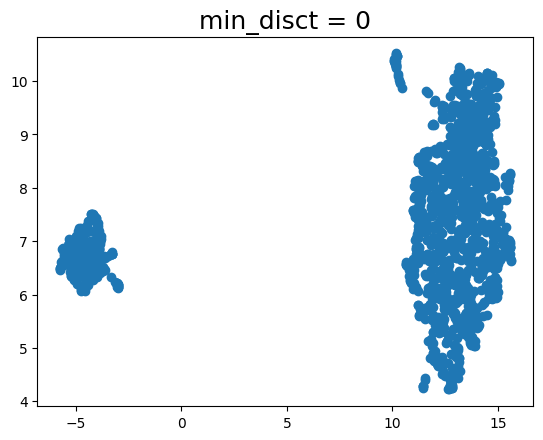

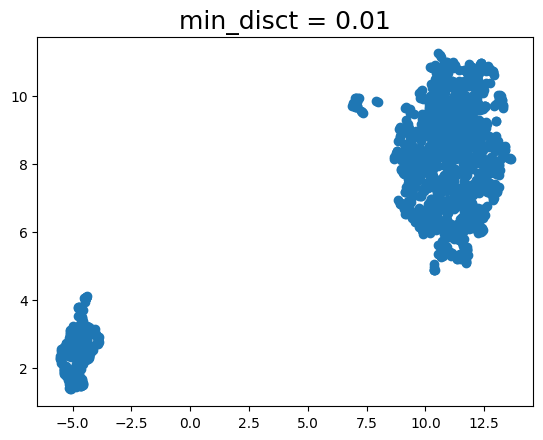

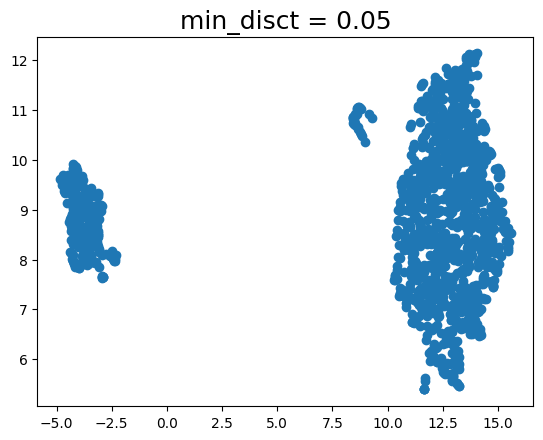

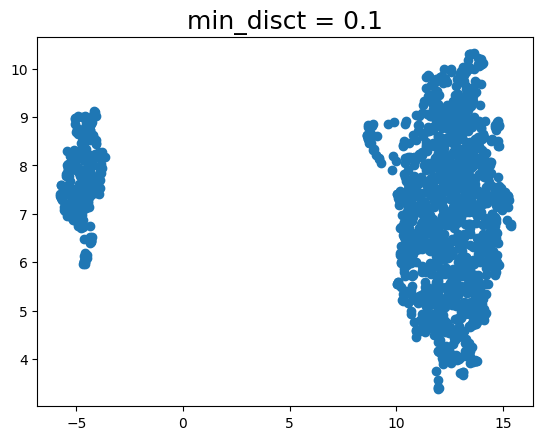

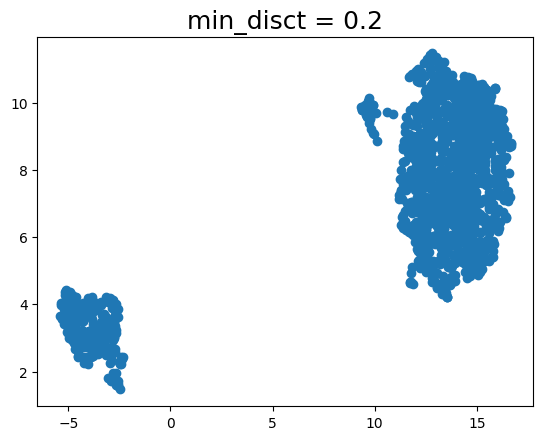

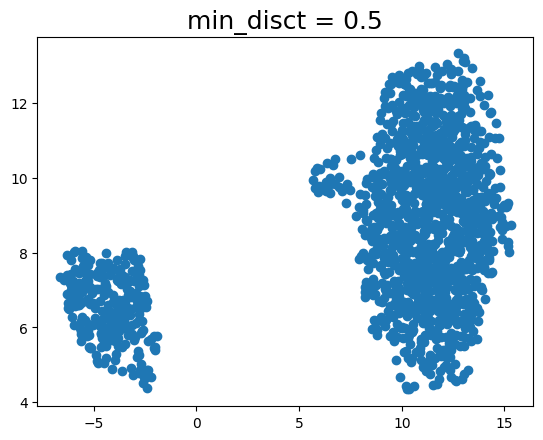

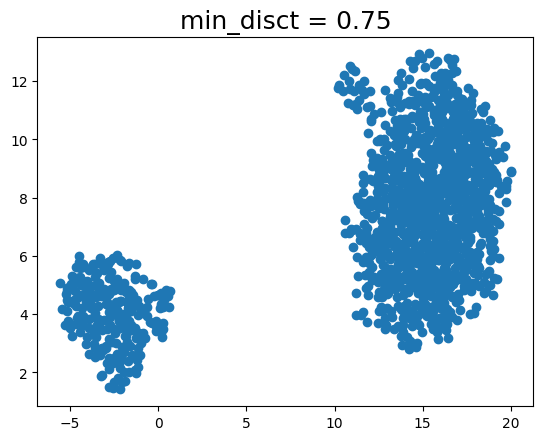

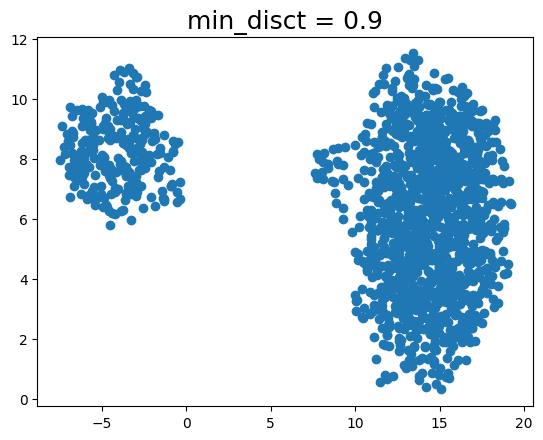

In [47]:
for d in (0, 0.01, 0.05, 0.1, 0.2, 0.5, 0.75, 0.9):
    draw_umap(n_neighbors=5, min_dist=d, title='min_disct = {}'.format(d))

In [48]:
fit = umap.UMAP(
        n_neighbors=5
    )
umap_embedding = fit.fit_transform(embeddings)

# Build a plotting DataFrame
plot_df = pd.DataFrame({
    "UMAP 1":  umap_embedding[:, 0],
    "UMAP 2":  umap_embedding[:, 1],
    "artist":  df["artist"],
    "title":   df["title"],
    "album":   df["album"],
})

fig = px.scatter(
    plot_df,
    x="UMAP 1",
    y="UMAP 2",
    color="artist",
    hover_name="title",             # song title shown as bold header on hover
    hover_data={                    # additional info in hover tooltip
        "artist": True,
        "album":  True,
        "UMAP 1": ":.3f",
        "UMAP 2": ":.3f",
    },
    title="UMAP Projection of Song Lyrics — Colored by Artist",
    template="plotly_dark",         # clean dark background, swap to "plotly_white" if preferred
    opacity=0.8,
    size_max=8,
)

fig.update_traces(
    marker=dict(size=6, line=dict(width=0.5, color="white")),
    selector=dict(mode="markers")
)

fig.update_layout(
    width=1100,
    height=700,
    legend=dict(
        title="Artist",
        itemsizing="constant",
        bgcolor="rgba(0,0,0,0.3)",
        bordercolor="rgba(255,255,255,0.2)",
        borderwidth=1
    ),
    font=dict(size=12),
    title_font=dict(size=16),
    xaxis=dict(showgrid=False, zeroline=False),
    yaxis=dict(showgrid=False, zeroline=False),
)

fig.show()